# DeepfakeFusionModel V7 — Stacked Cross-Attention + Temporal rPPG Tokens

**Paper**: *A Hybrid Spatial-Physiological Approach for Deepfake Detection using Swin Transformer and rPPG*

### Điểm nổi bật của kiến trúc

Mô hình kết hợp **Swin-Small** (spatial) và **rPPG 3D CNN** (temporal physiological)
thông qua cơ chế **Stacked Multi-Head Cross-Attention** (2 lớp, 8 heads).

Nhánh rPPG xử lý **T=32 frame liên tiếp** (≈ 1.2s video, hơn 1 chu kỳ tim),
xuất ra **BIO_TOKENS=16 temporal tokens** để Cross-Attention phân tích.

| Component | Chi tiết |
|---|---|
| Spatial backbone | **Swin-Small** (pretrained ImageNet, 50M params) |
| rPPG 3D CNN | 4 blocks, output `(B, 16, 64)` — 16 temporal tokens |
| Cross-Attention | **2 lớp xếp chồng**, mỗi lớp: MHA + FFN + Residual |
| Attention heads | 8 heads, softmax trên 16 vị trí temporal |

### Architecture Overview

```
RGB frame (middle of clip)  ──► Swin-Small (pretrained) ──► 768-d spatial vector
                                                                 │ (1 query token)
                                                    StackedCrossAttentionFusion
                                                    Layer 1: CrossAttn + FFN (8 heads)
                                                    Layer 2: CrossAttn + FFN (8 heads)
                                                    Q  = spatial            (B, 1, 768)
                                                    K=V= projected bio tokens (B, 16, 768)
                                                    softmax over 16 temporal positions
                                                                 │
YCrCb clip (T=32 frames) ──► 3D CNN rPPGNet ──► 16×64-d temporal tokens ──┘
                              Block 1:  spatial pool only (T preserved = 32)
                              Block 2:  spatial + temporal pool (T: 32→16)
                              Block 2b: spatial pool only, deeper features
                              Block 3:  adaptive pool → (16, 1, 1)
```

### Notebook Sections
0. Environment Setup
1. Dataset Preparation — Video → Face **Clips** (T=32 temporal sequences, `.npy`)
2. Dataset Class & DataLoader
3. Model Architecture V7 (Swin-S + 4-block rPPG + Stacked Cross-Attention)
4. Training Configuration
5. Training Loop
6. Evaluation — FF++ Validation
6.5. **Cross-Attention Weight Analysis** (empirical evaluation attention hoạt động đúng)
7. Cross-Dataset Evaluation — Celeb-DF-v2
8. Ablation Study (fair comparison)
9. Export & Save


---
## Section 0: Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q timm mediapipe scikit-learn matplotlib seaborn tqdm scipy
!wget -q -O /tmp/blaze_face_short_range.tflite \
  https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.3 MB/s eta 0:00:00


In [2]:
import os, glob, random, time, warnings, gc
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
import mediapipe as mp
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU:   {torch.cuda.get_device_name(0)}')
    print(f'VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU:   NVIDIA L4
VRAM:  23.7 GB


In [3]:
class Config:
    # ── Paths ──
    DRIVE_ROOT   = '/content/drive/MyDrive/DoAn_Nhom4'
    FF_ZIP       = f'{DRIVE_ROOT}/FaceForensics.zip'
    CELEB_ZIP    = f'{DRIVE_ROOT}/Celeb-DF-v2.zip'
    EXTRACT_DIR  = '/content/dataset'
    CLIPS_DIR    = '/content/clips'
    FF_CLIPS     = f'{CLIPS_DIR}/ffpp'
    CELEB_CLIPS  = f'{CLIPS_DIR}/celeb_df_v2'
    SAVE_DIR     = f'{DRIVE_ROOT}/weights_v7'

    # ── Clip Extraction ──
    # T=32 frames @ 25fps ≈ 1280ms window — đủ để capture hơn 1 chu kỳ tim (60bpm)
    T                 = 32
    CLIPS_PER_VIDEO   = 3     # clips trích từ mỗi video (giảm vì T dài hơn)
    FACE_CONFIDENCE   = 0.7
    FACE_PAD_X        = 0.15
    FACE_PAD_Y_TOP    = 0.40
    FACE_PAD_Y_BOTTOM = 0.20
    FACE_SIZE         = 112   # face crop resolution (px)

    # ── Model ──
    SPATIAL_DIM = 768    # Swin-Tiny output dim
    BIO_DIM     = 64     # rPPG 3D CNN per-token feature dim
    BIO_TOKENS  = T // 2 # số temporal token rPPG giữ lại cho Cross-Attention (=16)
                          # T_out > 1 để softmax không suy biến.
    ATTN_HEADS  = 8       # truyền vào nn.MultiheadAttention (tăng cho Stacked Cross-Attention)
    DROPOUT     = 0.3
    CROSS_ATTN_LAYERS = 2  # số lớp Cross-Attention xếp chồng

    # ── Training ──
    # BATCH_SIZE = 8 (giữ nguyên nhờ GPU A100/L4 có đủ VRAM)
    BATCH_SIZE           = 8
    EPOCHS               = 25
    FREEZE_SWIN_EPOCHS   = 3
    LR_SWIN              = 2e-5   # pretrained backbone: fine-tune nhẹ
    LR_OTHER             = 1e-4   # các layer mới: học nhanh hơn
    WEIGHT_DECAY         = 1e-4
    LABEL_SMOOTHING      = 0.05
    EARLY_STOP_PATIENCE  = 5
    GRAD_CLIP            = 1.0
    ABLATION_EPOCHS      = 10     # epochs cho ablation study

    SEED = 42


def set_seed(seed=Config.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
for k, v in vars(Config).items():
    if not k.startswith('_'):
        print(f'  {k:<22} = {v}')


  DRIVE_ROOT             = /content/drive/MyDrive/DoAn_Nhom4
  FF_ZIP                 = /content/drive/MyDrive/DoAn_Nhom4/FaceForensics.zip
  CELEB_ZIP              = /content/drive/MyDrive/DoAn_Nhom4/Celeb-DF-v2.zip
  EXTRACT_DIR            = /content/dataset
  CLIPS_DIR              = /content/clips
  FF_CLIPS               = /content/clips/ffpp
  CELEB_CLIPS            = /content/clips/celeb_df_v2
  SAVE_DIR               = /content/drive/MyDrive/DoAn_Nhom4/weights_v7
  T                      = 32
  CLIPS_PER_VIDEO        = 3
  FACE_CONFIDENCE        = 0.7
  FACE_PAD_X             = 0.15
  FACE_PAD_Y_TOP         = 0.4
  FACE_PAD_Y_BOTTOM      = 0.2
  FACE_SIZE              = 112
  SPATIAL_DIM            = 768
  BIO_DIM                = 64
  BIO_TOKENS             = 16
  ATTN_HEADS             = 8
  DROPOUT                = 0.3
  CROSS_ATTN_LAYERS      = 2
  BATCH_SIZE             = 8
  EPOCHS                 = 25
  FREEZE_SWIN_EPOCHS     = 3
  LR_SWIN                = 2e-05
  LR_OTH

---
## Section 1: Dataset Preparation — Video → Face Clips

**Đặc điểm chính của cách chuẩn bị dữ liệu:**  
Mỗi clip bao gồm **T=32 frame liên tiếp** từ same một video (≈ 1.2 giây ở 25fps),
lưu dưới dạng `.npy` shape `(32, FACE_SIZE, FACE_SIZE, 3)` (BGR).  
Đoạn video dài này cho phép nhánh rPPG phân tích biến động màu sắc theo thời gian
với độ phân giải cao, bao trùm hơn 1 chu kỳ tim.

> **Note:** Chỉ cần chạy Section 1 một lần. Nếu clips đã tồn tại, bỏ qua đến Section 2.

In [4]:
os.makedirs(Config.EXTRACT_DIR, exist_ok=True)

# Unzip FaceForensics++
ff_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'FaceForensics*'))
if not ff_folders:
    print('Extracting FaceForensics++...')
    !unzip -q "{Config.FF_ZIP}" -d "{Config.EXTRACT_DIR}/"
    ff_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'FaceForensics*'))
FF_ROOT = ff_folders[0]
print(f'FF++ root: {FF_ROOT}')
!ls "{FF_ROOT}"

# Unzip Celeb-DF-v2
celeb_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'Celeb*'))
if not celeb_folders:
    print('\nExtracting Celeb-DF-v2...')
    !unzip -q "{Config.CELEB_ZIP}" -d "{Config.EXTRACT_DIR}/"
    celeb_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'Celeb*'))
CELEB_ROOT = celeb_folders[0]
# Handle possible nested folder structure
if not any(os.path.isdir(os.path.join(CELEB_ROOT, d))
           for d in ['Celeb-real', 'Celeb-synthesis']):
    for s in glob.glob(os.path.join(CELEB_ROOT, '*')):
        if os.path.isdir(s) and 'Celeb-real' in os.listdir(s):
            CELEB_ROOT = s
            break
print(f'Celeb-DF-v2 root: {CELEB_ROOT}')
!ls "{CELEB_ROOT}"

Extracting FaceForensics++...
FF++ root: /content/dataset/FaceForensics++_C23
csv		   Deepfakes  FaceShifter  NeuralTextures
DeepFakeDetection  Face2Face  FaceSwap	   original

Extracting Celeb-DF-v2...
Celeb-DF-v2 root: /content/dataset/Celeb-synthesis
id0_id1_0000.mp4    id23_id37_0006.mp4	id32_id37_0000.mp4  id47_id42_0009.mp4
id0_id1_0001.mp4    id23_id37_0007.mp4	id32_id37_0002.mp4  id47_id43_0000.mp4
id0_id1_0002.mp4    id23_id37_0008.mp4	id32_id37_0004.mp4  id47_id43_0001.mp4
id0_id1_0003.mp4    id23_id37_0009.mp4	id32_id37_0005.mp4  id47_id43_0002.mp4
id0_id1_0005.mp4    id23_id38_0000.mp4	id32_id37_0006.mp4  id47_id43_0003.mp4
id0_id1_0006.mp4    id23_id38_0001.mp4	id32_id37_0007.mp4  id47_id43_0004.mp4
id0_id1_0007.mp4    id23_id38_0002.mp4	id32_id37_0008.mp4  id47_id43_0005.mp4
id0_id1_0009.mp4    id23_id38_0003.mp4	id32_id37_0009.mp4  id47_id43_0006.mp4
id0_id16_0000.mp4   id23_id38_0004.mp4	id32_id38_0000.mp4  id47_id43_0007.mp4
id0_id16_0001.mp4   id23_id38_0005.mp4	id32_

In [5]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

def extract_clips_from_video(video_path, output_dir, detector):
    '''
    Trích xuất face clips từ video dùng MediaPipe Tasks API (mediapipe >= 0.10.14).
    '''
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < Config.T:
        cap.release()
        return 0

    video_id = os.path.splitext(os.path.basename(video_path))[0]
    os.makedirs(output_dir, exist_ok=True)

    # ── Detect face trong frame đầu ─────────────────────────────────────────
    ret, first_frame = cap.read()
    if not ret:
        cap.release()
        return 0

    rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

    # Tasks API: use mp.Image instead of process(rgb)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result   = detector.detect(mp_image)

    if not result.detections:
        cap.release()
        return 0

    det = result.detections[0]
    bb  = det.bounding_box          # BoundingBox object (Tasks API)
    ih, iw = first_frame.shape[:2]

    # Tasks API returns pixel coords directly (not relative like solutions)
    x, y = bb.origin_x, bb.origin_y
    w, h = bb.width, bb.height

    px = int(w * Config.FACE_PAD_X)
    pt = int(h * Config.FACE_PAD_Y_TOP)
    pb = int(h * Config.FACE_PAD_Y_BOTTOM)
    x1 = max(0, x - px);      y1 = max(0, y - pt)
    x2 = min(iw, x + w + px); y2 = min(ih, y + h + pb)

    if (x2 - x1) < 20 or (y2 - y1) < 20:
        cap.release()
        return 0

    # ── Extract clips ──────────────────────────────────────────────────────────
    max_start  = total - Config.T
    clip_starts = np.linspace(0, max_start, Config.CLIPS_PER_VIDEO, dtype=int)
    saved = 0

    for clip_idx, start in enumerate(clip_starts):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start))
        frames = []
        for _ in range(Config.T):
            ret, frame = cap.read()
            if not ret:
                break
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                break
            frames.append(cv2.resize(crop, (Config.FACE_SIZE, Config.FACE_SIZE),
                                     interpolation=cv2.INTER_LINEAR))

        if len(frames) == Config.T:
            np.save(os.path.join(output_dir,
                                 f'{video_id}_clip{clip_idx:02d}.npy'),
                    np.stack(frames, axis=0))
            saved += 1

    cap.release()
    return saved


def process_video_folders(video_dirs, output_dir):
    '''Process all videos in the directory list — use MediaPipe Tasks API.'''
    # Initialize detector ONCE outside the loop (avoid overhead)
    base_options    = mp_python.BaseOptions(
        model_asset_path='/tmp/blaze_face_short_range.tflite')
    options         = mp_vision.FaceDetectorOptions(
        base_options=base_options,
        min_detection_confidence=Config.FACE_CONFIDENCE)
    detector = mp_vision.FaceDetector.create_from_options(options)

    videos = []
    for vdir in video_dirs:
        if not os.path.isdir(vdir):
            continue
        for ext in ['*.mp4', '*.avi', '*.mov', '*.mkv']:
            videos.extend(glob.glob(os.path.join(vdir, '**', ext), recursive=True))

    print(f'  Found {len(videos)} videos')
    total_clips = 0
    for vp in tqdm(videos, desc='  Extracting clips'):
        total_clips += extract_clips_from_video(vp, output_dir, detector)

    detector.close()
    n_clips = len(glob.glob(os.path.join(output_dir, '*.npy')))
    print(f'  Saved {n_clips} clips total.')
    return n_clips

print('Clip extraction functions ready.')

Clip extraction functions ready.


In [6]:
# ── Extract FF++ clips ─────────────────────────────────────────────────────────
print('=' * 60)
print('EXTRACTING CLIPS FROM FACEFORENSICS++ (C23)')
print('=' * 60)

ff_real_dir = os.path.join(Config.FF_CLIPS, 'real')
ff_fake_dir = os.path.join(Config.FF_CLIPS, 'fake')

if os.path.exists(ff_real_dir) and len(glob.glob(f'{ff_real_dir}/*.npy')) > 100:
    n_real = len(glob.glob(f'{ff_real_dir}/*.npy'))
    n_fake = len(glob.glob(f'{ff_fake_dir}/*.npy'))
    print(f'FF++ clips already exist — Real: {n_real}, Fake: {n_fake}. Skipping.')
else:
    print('\n[REAL] original/')
    process_video_folders([os.path.join(FF_ROOT, 'original')], ff_real_dir)

    print('\n[FAKE] 5 manipulation methods:')
    for method in ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']:
        mdir = os.path.join(FF_ROOT, method)
        if os.path.isdir(mdir):
            print(f'  >> {method}')
            process_video_folders([mdir], ff_fake_dir)
        else:
            print(f'  >> {method} NOT FOUND — skipping.')

print(f'\nFF++ done: Real={len(glob.glob(f"{ff_real_dir}/*.npy"))} clips, '
      f'Fake={len(glob.glob(f"{ff_fake_dir}/*.npy"))} clips')

EXTRACTING CLIPS FROM FACEFORENSICS++ (C23)

[REAL] original/
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 2811 clips total.

[FAKE] 5 manipulation methods:
  >> Deepfakes
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 2796 clips total.
  >> Face2Face
  Found 1000 videos


...

  Saved 2856 clips total.
  >> FaceSwap
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 2862 clips total.
  >> NeuralTextures
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 2862 clips total.

FF++ done: Real=2811 clips, Fake=2862 clips


In [7]:
# ── Extract Celeb-DF-v2 clips ─────────────────────────────────────────────────
print('=' * 60)
print('EXTRACTING CLIPS FROM CELEB-DF-v2')
print('=' * 60)

celeb_real_dir = os.path.join(Config.CELEB_CLIPS, 'real')
celeb_fake_dir = os.path.join(Config.CELEB_CLIPS, 'fake')

if os.path.exists(celeb_real_dir) and len(glob.glob(f'{celeb_real_dir}/*.npy')) > 100:
    print('Celeb-DF-v2 clips already exist. Skipping.')
else:
    print('[REAL] Celeb-real + YouTube-real')
    # Fix: Celeb folders are directly inside Config.EXTRACT_DIR
    process_video_folders(
        [os.path.join(Config.EXTRACT_DIR, 'Celeb-real'),
         os.path.join(Config.EXTRACT_DIR, 'YouTube-real')], celeb_real_dir)

    print('[FAKE] Celeb-synthesis')
    process_video_folders([os.path.join(Config.EXTRACT_DIR, 'Celeb-synthesis')], celeb_fake_dir)

print(f'Celeb-DF-v2 done: Real={len(glob.glob(f"{celeb_real_dir}/*.npy"))} clips, '
      f'Fake={len(glob.glob(f"{celeb_fake_dir}/*.npy"))} clips')

EXTRACTING CLIPS FROM CELEB-DF-v2
[REAL] Celeb-real + YouTube-real
  Found 890 videos


  Extracting clips:   0%|          | 0/890 [00:00<?, ?it/s]

  Saved 2502 clips total.
[FAKE] Celeb-synthesis
  Found 5639 videos


  Extracting clips:   0%|          | 0/5639 [00:00<?, ?it/s]

  Saved 16359 clips total.
Celeb-DF-v2 done: Real=2502 clips, Fake=16359 clips


---
## Section 2: Dataset Class & DataLoader

**Dataset design for temporal input:**
- Mỗi sample = 1 clip `.npy` có shape `(T, H, W, 3)` BGR
- **Spatial branch**: middle frame (index T//2) → RGB → Swin transform
- **Bio branch**: all T frames → YCrCb → normalize [0,1] → shape `(T, 3, 64, 64)`
- Geometric augmentation applied **consistently** to all T frames (same flip/rotate)
- ColorJitter applied only to the spatial branch:
  reason — bio branch needs to preserve YCrCb colors so the model learns temporal color variation

In [8]:
class DeepfakeDataset(Dataset):
    '''
    Temporal dual-stream dataset for deepfake detection.

    Load pre-extracted face clips (.npy, shape: T × H × W × 3 BGR).
    Returns:
        spatial_input : (3, 224, 224) float   — ImageNet-normalized RGB middle frame
        bio_input     : (T, 3, 64, 64) float  — YCrCb clip, normalized [0, 1]
        label         : scalar float           — 0=real, 1=fake
    '''
    BIO_SIZE = 112  # spatial size for rPPG input (high-res, color information needed)

    def __init__(self, npy_paths, labels, spatial_tf, augment=False):
        self.paths     = npy_paths
        self.labels    = labels
        self.spatial_tf = spatial_tf
        self.augment   = augment

    def __len__(self):
        return len(self.paths)

    def _augment_consistent(self, frames_bgr):
        '''
        Apply geometric augmentation to ALL frames with the same random state.
        IMPORTANT: must use the same transform for each frame to ensure
        temporal coherence — rPPG signal relies on consistency over time.
        '''
        do_flip   = random.random() > 0.5
        do_rotate = random.random() > 0.5
        angle = random.uniform(-10, 10) if do_rotate else 0.0

        h, w = frames_bgr[0].shape[:2]
        M = (cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
             if do_rotate else None)

        out = []
        for f in frames_bgr:
            if do_flip:
                f = cv2.flip(f, 1)
            if do_rotate:
                f = cv2.warpAffine(f, M, (w, h),
                                   borderMode=cv2.BORDER_REPLICATE)
            out.append(f)
        return out

    def __getitem__(self, idx):
        clip_bgr = np.load(self.paths[idx], allow_pickle=False)  # (T, H, W, 3)
        label    = self.labels[idx]

        frames = [clip_bgr[t] for t in range(Config.T)]

        # Geometric augmentation — consistent for all frames
        if self.augment:
            frames = self._augment_consistent(frames)

        mid = Config.T // 2  # index of middle frame in the clip

        # ── Spatial Branch: RGB middle frame → Swin ─────────────────────────
        frame_spatial = frames[mid].copy()
        if self.augment and random.random() > 0.5:
            if random.random() > 0.5:
                # JPEG Compression Augmentation
                quality = random.randint(30, 95)
                encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
                _, buf = cv2.imencode('.jpg', frame_spatial, encode_param)
                frame_spatial = cv2.imdecode(buf, cv2.IMREAD_COLOR)
            else:
                # Downscale-Upscale Augmentation
                scale = random.uniform(0.5, 0.9)
                h, w = frame_spatial.shape[:2]
                small = cv2.resize(frame_spatial, (int(w * scale), int(h * scale)))
                frame_spatial = cv2.resize(small, (w, h))

        frame_rgb = cv2.cvtColor(frame_spatial, cv2.COLOR_BGR2RGB)
        img_pil   = Image.fromarray(frame_rgb)
        spatial_input = self.spatial_tf(img_pil)  # (3, 224, 224)

        # ── Bio Branch: YCrCb clip → rPPG 3D CNN ────────────────────────────
        bio_frames = []
        for f in frames:
            ycrcb = cv2.cvtColor(f, cv2.COLOR_BGR2YCrCb)
            ycrcb = cv2.resize(ycrcb, (self.BIO_SIZE, self.BIO_SIZE),
                               interpolation=cv2.INTER_LINEAR)
            bio_frames.append(ycrcb)

        # (T, H, W, 3) uint8 → (T, 3, H, W) float [0, 1]
        bio_array = np.stack(bio_frames, axis=0).astype(np.float32) / 255.0
        bio_input = torch.from_numpy(bio_array).permute(0, 3, 1, 2)  # (T, 3, H, W)

        return spatial_input, bio_input, torch.tensor(label, dtype=torch.float32)


print('DeepfakeDataset defined.')

DeepfakeDataset defined.


In [9]:
train_spatial_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_spatial_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def collect_npy(base_dir):
    '''Collect .npy clip paths and labels from real/ and fake/ subfolders.'''
    paths, labels = [], []
    for label_name, label_val in [('real', 0), ('fake', 1)]:
        folder = os.path.join(base_dir, label_name)
        if not os.path.exists(folder):
            continue
        for f in sorted(glob.glob(os.path.join(folder, '*.npy'))):
            paths.append(f)
            labels.append(label_val)
    return paths, labels


def get_video_id(npy_path):
    '''
    Extract video_id from clip name.
    Format: "{video_id}_clip{NN}.npy" → "{video_id}"
    Use rfind to avoid false-split if video_id contains "_clip" in the name.
    '''
    name = os.path.splitext(os.path.basename(npy_path))[0]
    idx  = name.rfind('_clip')
    return name[:idx] if idx != -1 else name


# ── Collect FF++ data ──────────────────────────────────────────────────────────
ff_paths, ff_labels = collect_npy(Config.FF_CLIPS)
print(f'FF++ total: {len(ff_paths)} clips '
      f'(Real: {ff_labels.count(0)}, Fake: {ff_labels.count(1)})')

# ── Split by video ID — avoid data leakage (frames from same video in same split) ─────
video_ids = sorted(set(get_video_id(p) for p in ff_paths))
random.shuffle(video_ids)
split = int(len(video_ids) * 0.8)
train_vids = set(video_ids[:split])
val_vids   = set(video_ids[split:])

train_paths, train_labels = [], []
val_paths,   val_labels   = [], []

for p, l in zip(ff_paths, ff_labels):
    if get_video_id(p) in train_vids:
        train_paths.append(p);  train_labels.append(l)
    else:
        val_paths.append(p);    val_labels.append(l)

print(f'FF++ Train: {len(train_paths)} clips '
      f'(Real: {train_labels.count(0)}, Fake: {train_labels.count(1)})')
print(f'FF++ Val:   {len(val_paths)} clips '
      f'(Real: {val_labels.count(0)}, Fake: {val_labels.count(1)})')

# ── Celeb-DF-v2: cross-dataset test (untouched during train/val) ────────────
celeb_paths, celeb_labels = collect_npy(Config.CELEB_CLIPS)
print(f'\nCeleb-DF-v2 Test: {len(celeb_paths)} clips '
      f'(Real: {celeb_labels.count(0)}, Fake: {celeb_labels.count(1)})')

FF++ total: 5673 clips (Real: 2811, Fake: 2862)
FF++ Train: 4536 clips (Real: 2217, Fake: 2319)
FF++ Val:   1137 clips (Real: 594, Fake: 543)

Celeb-DF-v2 Test: 18861 clips (Real: 2502, Fake: 16359)


In [10]:
train_dataset = DeepfakeDataset(train_paths, train_labels, train_spatial_tf, augment=True)
val_dataset   = DeepfakeDataset(val_paths,   val_labels,   val_spatial_tf, augment=False)
test_dataset  = DeepfakeDataset(celeb_paths, celeb_labels, val_spatial_tf, augment=False)

# WeightedRandomSampler to balance class imbalance (FF++ has more fakes than reals)
counts         = np.bincount(train_labels)
sample_weights = [1.0 / counts[l] for l in train_labels]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights),
                                       replacement=True)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE,
                          sampler=sampler, num_workers=0,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'DataLoaders ready:')
print(f'  Train: {len(train_loader)} batches × {Config.BATCH_SIZE}')
print(f'  Val:   {len(val_loader)} batches')
print(f'  Test:  {len(test_loader)} batches (Celeb-DF-v2)')

DataLoaders ready:
  Train: 567 batches × 8
  Val:   143 batches
  Test:  2358 batches (Celeb-DF-v2)


---
## Section 3: Model Architecture — DeepfakeFusionModel V7

### rPPGNetwork3D — outputs a TOKEN SEQUENCE (16 tokens)
3D CNN comprising 4 blocks processing T=32 YCrCb frames. The final block uses
`AdaptiveAvgPool3d((BIO_TOKENS,1,1))` — only spatial pooling, **preserving `BIO_TOKENS=16`
temporal tokens**. This is a necessary design for Cross-Attention to have true
mathematical meaning.

### StackedCrossAttentionFusion — 2-layer stacked cross-attention
`nn.MultiheadAttention` với `num_heads = 8`, stacked 2 layers.
Each layer consists of: Multi-Head Cross-Attention + FFN + Residual + LayerNorm.
- **Query**: 1 token from spatial branch (Swin-Small) — *"spatial features on the face"*
- **Key/Value**: 16 token from bio branch (rPPG) — *"biological signals at 16 time segments"*

The first layer learns to select relevant temporal information. The second layer further refines
based on the fusion results of the previous layer, allowing integration at multiple abstraction levels.


In [11]:
class rPPGNetwork3D(nn.Module):
    '''
    Temporal Physiological Feature Extractor — TOKEN SEQUENCE output.

    Input:  (B, T, 3, 64, 64) — YCrCb face clips (T=32 consecutive frames)
    Output: (B, BIO_TOKENS, BIO_DIM) — sequence of 16 temporal physiological tokens

    3D CNN extracts rPPG signals from consecutive frames. With T=32 frames
    (≈ 1.2s video), the network captures more than 1 complete heart cycle (60bpm = 1s/beat),
    providing sufficient biological information for Cross-Attention.

    Block design:
      Block 1:  (B, 3,   T,    64, 64) → (B, 32,  T,    32, 32)  [pool spatial only]
      Block 2:  (B, 32,  T,    32, 32) → (B, 64,  T//2, 16, 16)  [pool spatial + temporal]
      Block 2b: (B, 64,  T//2, 16, 16) → (B, 128, T//2, 8,  8)   [pool spatial only, deeper]
      Block 3:  (B, 128, T//2, 8,  8)  → (B, BIO_DIM, BIO_TOKENS, 1, 1) [adaptive pool]
    '''
    def __init__(self, bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS):
        super().__init__()
        self.bio_tokens = bio_tokens
        self.features = nn.Sequential(
            # Block 1: pool spatial only — keep full temporal resolution
            nn.Conv3d(3, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),

            # Block 2: pool both temporal and spatial (T: 32 → 16)
            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),

            # Block 2b: deeper features — pool ONLY spatial, KEEP temporal
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),

            # Block 3: final features — adaptive pool preserve bio_tokens temporal positions
            nn.Conv3d(128, bio_dim, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(bio_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((bio_tokens, 1, 1))   # preserve temporal dimension
        )

    def forward(self, x):
        # x: (B, T, 3, H, W) — dataset format
        # → (B, 3, T, H, W) — 3D conv expects channel-first
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        feat = self.features(x)                  # (B, bio_dim, bio_tokens, 1, 1)
        feat = feat.squeeze(-1).squeeze(-1)       # (B, bio_dim, bio_tokens)
        return feat.permute(0, 2, 1).contiguous() # (B, bio_tokens, bio_dim) — token sequence


In [12]:
class CrossAttentionLayer(nn.Module):
    '''
    A single Cross-Attention layer includes:
    - Multi-Head Cross-Attention (Q from spatial, K/V from bio)
    - Residual connection + LayerNorm
    - Feed-Forward Network (FFN) + Residual connection + LayerNorm
    '''
    def __init__(self, spatial_dim, num_heads, dropout=0.1, ffn_ratio=4):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=spatial_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(spatial_dim)
        self.norm2 = nn.LayerNorm(spatial_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        # Feed-Forward Network (FFN)
        ffn_hidden = spatial_dim // ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(spatial_dim, ffn_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden, spatial_dim),
        )

    def forward(self, query, key_value, return_attn=False):
        '''
        query:     (B, 1, D) — spatial token
        key_value: (B, BIO_TOKENS, D) — projected bio tokens
        '''
        # Cross-Attention + Residual + LayerNorm
        attended, attn_w = self.cross_attn(
            query, key_value, key_value,
            need_weights=True, average_attn_weights=True)
        query = self.norm1(query + self.dropout1(attended))

        # FFN + Residual + LayerNorm
        query = self.norm2(query + self.dropout2(self.ffn(query)))

        if return_attn:
            return query, attn_w
        return query


class StackedCrossAttentionFusion(nn.Module):
    '''
    Stacked Multi-Head Cross-Attention Fusion.

    Spatial features (Swin) → Query Q   : 1 token
    Bio features (rPPG 3D)  → Key/Value : BIO_TOKENS=16 tokens

    Consists of N stacked CrossAttentionLayers. Each layer refines Q based on
    information from K/V, allowing the model to learn to combine spatial and temporal
    at multiple levels of abstraction.
    '''
    def __init__(self, spatial_dim=Config.SPATIAL_DIM, bio_dim=Config.BIO_DIM,
                 num_heads=Config.ATTN_HEADS, num_layers=Config.CROSS_ATTN_LAYERS,
                 dropout=0.1):
        super().__init__()
        assert spatial_dim % num_heads == 0, (
            f'spatial_dim ({spatial_dim}) must be divisible by num_heads ({num_heads})')

        # Project each bio token (bio_dim-d) to spatial_dim (768-d) to act as K, V
        self.bio_proj = nn.Sequential(
            nn.Linear(bio_dim, spatial_dim),
            nn.LayerNorm(spatial_dim)
        )

        # N stacked Cross-Attention layers
        self.layers = nn.ModuleList([
            CrossAttentionLayer(spatial_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, spatial_feat, bio_tokens, return_attn=False):
        '''
        spatial_feat : (B, 768)              — from Swin Transformer
        bio_tokens   : (B, BIO_TOKENS, 64)    — from rPPG 3D CNN (sequence!)
        Returns      : (B, 768) fused features
                       [+ (B, BIO_TOKENS) attention weights if return_attn=True]
        '''
        Q  = spatial_feat.unsqueeze(1)        # (B, 1, 768)
        KV = self.bio_proj(bio_tokens)        # (B, BIO_TOKENS, 768)

        attn_w_last = None
        for layer in self.layers:
            if return_attn:
                Q, attn_w_last = layer(Q, KV, return_attn=True)
            else:
                Q = layer(Q, KV)

        fused = Q.squeeze(1)                  # (B, 768)

        if return_attn:
            return fused, attn_w_last.squeeze(1)  # attn_w: (B, BIO_TOKENS)
        return fused


In [13]:
class DeepfakeFusionModelV7(nn.Module):
    '''
    Deepfake Detection Model V7 — Stacked Multi-Token Cross-Attention.

    Pipeline:
        RGB frame (middle of T-frame clip)
          → Swin-Small (pretrained, ImageNet)
          → 768-d spatial feature (1 query token)
                    \\
                     StackedCrossAttentionFusion (8 heads, 2 layers, K/V = 16 temporal tokens)
                    /                    → MLP → Sigmoid
        YCrCb clip (T=32 frames)
          → rPPGNetwork3D (3D CNN, 4 blocks)
          → (BIO_TOKENS=16, 64) temporal physiological token sequence
    '''
    def __init__(self, pretrained_swin=True):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=pretrained_swin,
            num_classes=0
        )
        self.rppg_net = rPPGNetwork3D(
            bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS)
        self.cross_attention = StackedCrossAttentionFusion(
            spatial_dim=Config.SPATIAL_DIM,
            bio_dim=Config.BIO_DIM,
            num_heads=Config.ATTN_HEADS,
            num_layers=Config.CROSS_ATTN_LAYERS,
            dropout=0.1
        )
        self.classifier = nn.Sequential(
            nn.Linear(Config.SPATIAL_DIM, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(Config.DROPOUT),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(Config.DROPOUT),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Auxiliary classifier to provide direct supervision to the rPPG branch
        self.aux_classifier = nn.Sequential(
            nn.Linear(Config.BIO_DIM, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, spatial_input, bio_input, return_attn=False):
        spatial_feat = self.swin(spatial_input)           # (B, 768)
        bio_tokens   = self.rppg_net(bio_input)            # (B, BIO_TOKENS, 64)

        # Global average pool the temporal tokens for auxiliary classification
        bio_pooled = bio_tokens.mean(dim=1)                # (B, 64)
        aux_out    = self.aux_classifier(bio_pooled)       # (B, 1)

        if return_attn:
            fused, attn_w = self.cross_attention(
                spatial_feat, bio_tokens, return_attn=True)
            return self.classifier(fused), aux_out, attn_w  # Return main, aux, and attn

        fused = self.cross_attention(spatial_feat, bio_tokens)
        return self.classifier(fused), aux_out               # Return main and aux


# ── Verify model + verify attention is non-degenerate ──────────────────────────────
model = DeepfakeFusionModelV7(pretrained_swin=True).to(device)

dummy_s = torch.randn(4, 3, 224, 224).to(device)
dummy_b = torch.randn(4, Config.T, 3, 112, 112).to(device)
with torch.no_grad():
    out, out_aux = model(dummy_s, dummy_b)
    out_attn, out_aux_attn, attn_w = model(dummy_s, dummy_b, return_attn=True)

assert out.shape == (4, 1), f'Unexpected output shape: {out.shape}'
assert attn_w.shape == (4, Config.BIO_TOKENS), f'Unexpected attn shape: {attn_w.shape}'

print(f'Forward pass OK. Output shape: {out.shape}')
print(f'Attention weights shape: {attn_w.shape}  (B={4}, BIO_TOKENS={Config.BIO_TOKENS})')
print(f'Attention weights sum per sample (should ≈ 1.0): '
      f'{attn_w.sum(dim=1).cpu().numpy()}')
print(f'Sample attention distribution (row 0): {attn_w[0].cpu().numpy().round(4)}')
print(f'\nStd across the {Config.BIO_TOKENS} token weights (row 0): {attn_w[0].std().item():.6f}')
print('(Non-zero std confirms softmax produces a non-trivial distribution.)')

total_p = sum(p.numel() for p in model.parameters())
print(f'\nParameter count:')
print(f'  Swin Transformer : {sum(p.numel() for p in model.swin.parameters()):>12,}')
print(f'  rPPG 3D CNN      : {sum(p.numel() for p in model.rppg_net.parameters()):>12,}')
print(f'  CrossAttention   : {sum(p.numel() for p in model.cross_attention.parameters()):>12,}')
print(f'  Classifier       : {sum(p.numel() for p in model.classifier.parameters()):>12,}')
print(f'  TOTAL            : {total_p:>12,}')

del dummy_s, dummy_b, out, out_attn, attn_w
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

Forward pass OK. Output shape: torch.Size([4, 1])
Attention weights shape: torch.Size([4, 16])  (B=4, BIO_TOKENS=16)
Attention weights sum per sample (should ≈ 1.0): [1.0690789 0.9984856 1.0261267 1.0142789]
Sample attention distribution (row 0): [0.0662 0.0681 0.0698 0.0687 0.0685 0.068  0.0521 0.0693 0.0678 0.0674
 0.0677 0.0687 0.0689 0.062  0.0611 0.0747]

Std across the 16 token weights (row 0): 0.004956
(Non-zero std confirms softmax produces a non-trivial distribution.)

Parameter count:
  Swin Transformer :   48,837,258
  rPPG 3D CNN      :      499,392
  CrossAttention   :    5,374,080
  Classifier       :      230,657
  TOTAL            :   54,945,740


---
## Section 4 & 5: Training Configuration & Loop

In [14]:
class LabelSmoothingBCELoss(nn.Module):
    '''BCELoss + label smoothing to reduce overconfidence.'''
    def __init__(self, smoothing=Config.LABEL_SMOOTHING):
        super().__init__()
        self.s   = smoothing
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        target_smooth = target * (1 - self.s) + 0.5 * self.s
        return self.bce(pred, target_smooth)


class EarlyStopping:
    '''Stop training when val AUC does not improve after `patience` epochs.'''
    def __init__(self, patience=Config.EARLY_STOP_PATIENCE, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = None
        self.stop      = False

    def __call__(self, score):
        if self.best is None:
            self.best = score
        elif score < self.best + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best   = score
            self.counter = 0


def compute_eer(y_true, y_scores):
    '''Equal Error Rate (%) via brentq — more accurate than nanargmin.'''
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
    return eer * 100


print('Training utilities ready.')

Training utilities ready.


In [15]:
os.makedirs(Config.SAVE_DIR, exist_ok=True)

criterion = LabelSmoothingBCELoss()

# Differential LR: Swin pretrained → small; new layers → larger
swin_params  = list(model.swin.parameters())
other_params = [p for n, p in model.named_parameters()
                if not n.startswith('swin')]

optimizer = optim.AdamW([
    {'params': swin_params,  'lr': Config.LR_SWIN},
    {'params': other_params, 'lr': Config.LR_OTHER}
], weight_decay=Config.WEIGHT_DECAY)

scheduler       = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=Config.EPOCHS, eta_min=1e-7)
early_stopping  = EarlyStopping()

history = defaultdict(list)
best_val_auc = 0.0
best_epoch   = 0
best_path    = ''

print(f'TRAINING START  |  {Config.EPOCHS} epochs  |  batch_size={Config.BATCH_SIZE}')
print(f'Swin LR: {Config.LR_SWIN}  |  Other LR: {Config.LR_OTHER}')
print('=' * 90)

for epoch in range(1, Config.EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    if epoch == Config.FREEZE_SWIN_EPOCHS + 1:
        for p in model.swin.parameters():
            p.requires_grad = True
        print(f'>>> Epoch {epoch}: Unfreezing Swin backbone')
    elif epoch <= Config.FREEZE_SWIN_EPOCHS:
        for p in model.swin.parameters():
            p.requires_grad = False

    model.train()
    tr_loss, tr_corr, tr_total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f'Ep {epoch:02d} [Train]', leave=False)
    for imgs, bios, labels in pbar:
        imgs, bios, labels = imgs.to(device), bios.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, aux_outputs = model(imgs, bios)
        outputs = outputs.squeeze(1)
        aux_outputs = aux_outputs.squeeze(1)

        main_loss = criterion(outputs, labels)
        aux_loss  = criterion(aux_outputs, labels)
        loss = main_loss + 0.3 * aux_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * imgs.size(0)
        preds     = (outputs > 0.5).float()
        tr_corr  += (preds == labels).sum().item()
        tr_total += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}',
                         acc=f'{tr_corr/tr_total:.4f}')

    tr_loss /= tr_total
    tr_acc   = tr_corr / tr_total

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    va_loss, va_corr, va_total = 0.0, 0, 0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for imgs, bios, labels in tqdm(val_loader, desc=f'Ep {epoch:02d} [Val]',
                                       leave=False):
            imgs, bios, labels = imgs.to(device), bios.to(device), labels.to(device)
            outputs, aux_outputs = model(imgs, bios)
            outputs = outputs.squeeze(1)
            aux_outputs = aux_outputs.squeeze(1)

            main_loss = criterion(outputs, labels)
            aux_loss  = criterion(aux_outputs, labels)
            loss = main_loss + 0.3 * aux_loss

            va_loss  += loss.item() * imgs.size(0)
            preds     = (outputs > 0.5).float()
            va_corr  += (preds == labels).sum().item()
            va_total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(outputs.cpu().numpy())

    va_loss /= va_total
    va_acc   = va_corr / va_total
    va_auc   = roc_auc_score(all_labels, all_probs)
    va_eer   = compute_eer(all_labels, all_probs)

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['val_auc'].append(va_auc)
    history['val_eer'].append(va_eer)
    history['lr'].append(lr_now)

    marker = ''
    if va_auc > best_val_auc:
        best_val_auc = va_auc
        best_epoch   = epoch
        best_path    = os.path.join(Config.SAVE_DIR, 'best_model_v7.pth')
        torch.save(model.state_dict(), best_path)
        marker = '  << BEST'

    if epoch % 5 == 0:
        ckpt = os.path.join(Config.SAVE_DIR, f'v7_ep{epoch:02d}.pth')
        torch.save(model.state_dict(), ckpt)

    elapsed = time.time() - t0
    print(f'Ep {epoch:02d}/{Config.EPOCHS} | '
          f'TrL {tr_loss:.4f} TrA {tr_acc:.4f} | '
          f'VaL {va_loss:.4f} VaA {va_acc:.4f} AUC {va_auc:.4f} EER {va_eer:.2f}% | '
          f'LR {lr_now:.2e} | {elapsed:.0f}s{marker}')

    early_stopping(va_auc)
    if early_stopping.stop:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

    torch.cuda.empty_cache()

print(f'\nBest: Epoch {best_epoch}  |  Val AUC = {best_val_auc:.4f}')
print(f'Saved to: {best_path}')

TRAINING START  |  25 epochs  |  batch_size=8
Swin LR: 2e-05  |  Other LR: 0.0001


Ep 01 [Train]:   0%|          | 0/567 [00:00<?, ?it/s]

Ep 01 [Val]:   0%|          | 0/143 [00:00<?, ?it/s]

Ep 01/25 | TrL 0.9235 TrA 0.5185 | VaL 0.8925 VaA 0.5356 AUC 0.5671 EER 46.22% | LR 1.99e-05 | 158s  << BEST


Ep 02 [Train]:   0%|          | 0/567 [00:00<?, ?it/s]

...

Ep 14 [Val]:   0%|          | 0/143 [00:00<?, ?it/s]

Ep 14/25 | TrL 0.5889 TrA 0.8973 | VaL 0.8188 VaA 0.8232 AUC 0.9195 EER 15.29% | LR 8.19e-06 | 179s


Ep 15 [Train]:   0%|          | 0/567 [00:00<?, ?it/s]

Ep 15 [Val]:   0%|          | 0/143 [00:00<?, ?it/s]

Ep 15/25 | TrL 0.5659 TrA 0.9149 | VaL 0.7965 VaA 0.8347 AUC 0.9084 EER 16.50% | LR 6.98e-06 | 180s

Early stopping triggered at epoch 15.

Best: Epoch 10  |  Val AUC = 0.9255
Saved to: /content/drive/MyDrive/DoAn_Nhom4/weights_v7/best_model_v7.pth


In [ ]:
# Training curves
epochs_r = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training History — DeepfakeFusionModel V7', fontsize=14, fontweight='bold')

axes[0,0].plot(epochs_r, history['train_loss'], 'o-', color='#FF6B6B',
               label='Train', markersize=4)
axes[0,0].plot(epochs_r, history['val_loss'],   's-', color='#4ECDC4',
               label='Val',   markersize=4)
axes[0,0].set(title='Loss', xlabel='Epoch', ylabel='Loss'); axes[0,0].legend()

axes[0,1].plot(epochs_r, history['train_acc'], 'o-', color='#FF6B6B',
               label='Train', markersize=4)
axes[0,1].plot(epochs_r, history['val_acc'],   's-', color='#4ECDC4',
               label='Val',   markersize=4)
axes[0,1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); axes[0,1].legend()

axes[1,0].plot(epochs_r, history['val_auc'], 's-', color='#45B7D1',
               linewidth=2, markersize=4, label='Val AUC')
axes[1,0].set(title='Validation AUC-ROC', xlabel='Epoch', ylabel='AUC')
axes[1,0].legend()

axes[1,1].plot(epochs_r, history['val_eer'], 's-', color='#96CEB4',
               linewidth=2, markersize=4, label='Val EER')
axes[1,1].set(title='Validation EER (lower=better)', xlabel='Epoch', ylabel='EER (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'training_curves_v7.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Evaluation — FF++ Validation

Loaded best model from epoch 10


Eval: FaceForensics++ Val (C23):   0%|          | 0/143 [00:00<?, ?it/s]


RESULTS — FaceForensics++ Val (C23)
  Accuracy  : 84.43%
  AUC-ROC   : 0.9255
  EER       : 15.10%
  F1-Score  : 0.8432
  Precision : 0.8123
  Recall    : 0.8766

              precision    recall  f1-score   support

        Real       0.88      0.81      0.85       594
        Fake       0.81      0.88      0.84       543

    accuracy                           0.84      1137
   macro avg       0.85      0.85      0.84      1137
weighted avg       0.85      0.84      0.84      1137



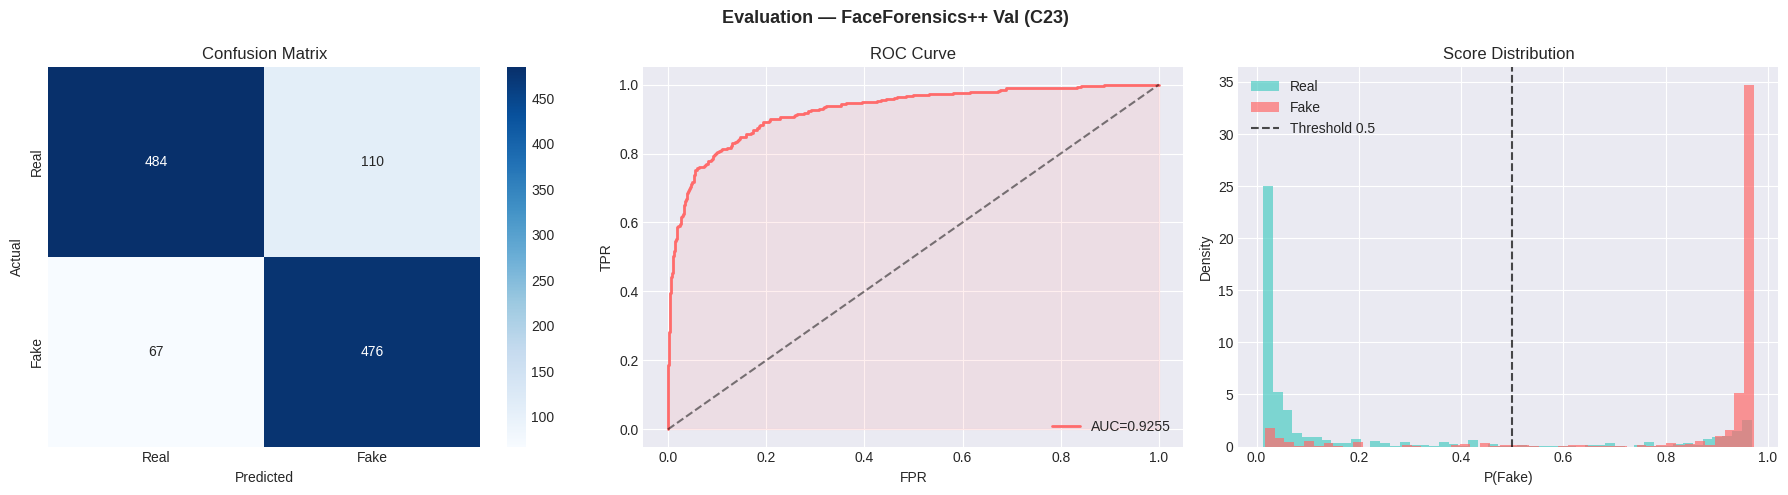

In [18]:
def evaluate_model(model, dataloader, dataset_name='Dataset'):
    '''Full evaluation: metrics + Confusion Matrix + ROC + Score Distribution.'''
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for imgs, bios, labels in tqdm(dataloader, desc=f'Eval: {dataset_name}'):
            imgs, bios = imgs.to(device), bios.to(device)
            out = model(imgs, bios)
            # Handle tuple output from V7 model and single tensor from ablation models
            outputs = out[0].squeeze(1) if isinstance(out, tuple) else out.squeeze(1)
            all_labels.extend(labels.numpy())
            all_probs.extend(outputs.cpu().numpy())

    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob > 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    eer  = compute_eer(y_true, y_prob)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)

    print(f'\n{"=" * 52}')
    print(f'RESULTS — {dataset_name}')
    print(f'{"=" * 52}')
    print(f'  Accuracy  : {acc * 100:.2f}%')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  EER       : {eer:.2f}%')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Evaluation — {dataset_name}', fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'], ax=axes[0])
    axes[0].set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='#FF6B6B', linewidth=2, label=f'AUC={auc:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', alpha=0.5)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#FF6B6B')
    axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[1].legend(loc='lower right')

    axes[2].hist(y_prob[y_true==0], bins=50, alpha=0.7, color='#4ECDC4',
                 label='Real', density=True)
    axes[2].hist(y_prob[y_true==1], bins=50, alpha=0.7, color='#FF6B6B',
                 label='Fake', density=True)
    axes[2].axvline(0.5, color='black', ls='--', alpha=0.7, label='Threshold 0.5')
    axes[2].set(xlabel='P(Fake)', ylabel='Density', title='Score Distribution')
    axes[2].legend()

    plt.tight_layout()
    safe_name = dataset_name.lower().replace(' ','_').replace('(','').replace(')','')
    plt.savefig(os.path.join(Config.SAVE_DIR, f'eval_{safe_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'auc': auc, 'eer': eer,
            'f1': f1, 'precision': prec, 'recall': rec}


# Load best checkpoint
model.load_state_dict(torch.load(best_path, map_location=device))
print(f'Loaded best model from epoch {best_epoch}')

ff_results = evaluate_model(model, val_loader, 'FaceForensics++ Val (C23)')


---
## Section 6.5: Cross-Attention Weight Analysis (empirical evaluation)

This section exists to empirically prove that `softmax` in
`CrossAttentionFusion` **works properly** — creating a probability distribution
over the actual temporal tokens, not degenerating to a constant.

With `K, V` having multiple tokens, attention weights form a distribution that can vary between
samples, across training epochs, and (ideally) between Real vs Fake classes.

If the chart below shows **non-zero variance** and **non-uniform distribution
1/4 = 0.25 for all tokens**, it's evidence that attention actually "works"
rather than being a disguised fixed linear projection.


Extracting attention:   0%|          | 0/143 [00:00<?, ?it/s]

Collected attention weights: (504, 16)
Mean weight per token (all samples): [0.4668 0.0141 0.0203 0.0197 0.0197 0.0196 0.0196 0.0196 0.0194 0.0193
 0.0193 0.0193 0.0193 0.02   0.0106 0.2733]
Std  weight per token (all samples): [0.1297 0.0077 0.0081 0.0073 0.0069 0.0067 0.0066 0.0066 0.0065 0.0065
 0.0066 0.0069 0.007  0.0075 0.0048 0.1204]
Per-sample std (mean over samples): 0.1287
  → If std ≈ 0 across all samples: attention is almost uniform,
    mathematically valid but weak in "dynamic selectivity".
  → If std > 0 clearly: model is distinguishing between different temporal tokens.


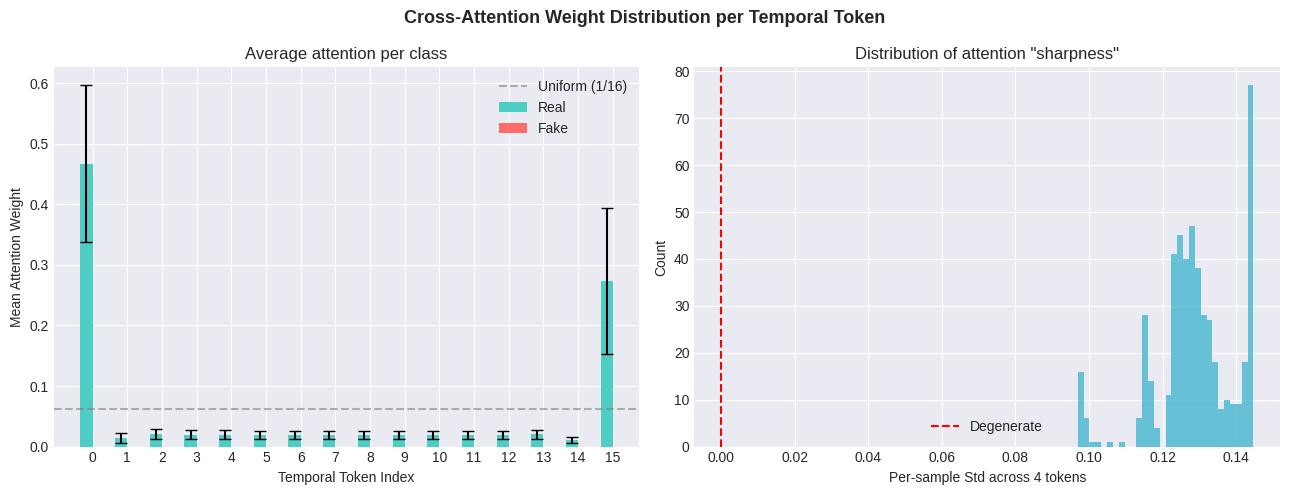


Note for paper: if Real vs Fake shows different attention patterns
attention patterns (e.g., Fake focuses heavily on 1-2 specific tokens, Real is more evenly distributed
this is direct empirical evidence supporting the claim "the network
focuses on regions where biological liveness is disrupted" trong Conclusion.


In [20]:
@torch.no_grad()
def extract_attention_weights(model, dataloader, max_samples=500):
    '''
    Run forward with return_attn=True on the val set, collecting:
      - attn_weights: (N, BIO_TOKENS) — attention weights per sample
      - labels:       (N,)            — 0=real, 1=fake
    '''
    model.eval()
    all_attn, all_labels = [], []
    n_collected = 0

    for imgs, bios, labels in tqdm(dataloader, desc='Extracting attention'):
        imgs, bios = imgs.to(device), bios.to(device)
        # FIX: The model returns 3 values when return_attn=True (main_out, aux_out, attn_w)
        _, _, attn_w = model(imgs, bios, return_attn=True)   # (B, BIO_TOKENS)
        all_attn.append(attn_w.cpu().numpy())
        all_labels.append(labels.numpy())
        n_collected += imgs.size(0)
        if n_collected >= max_samples:
            break

    return np.concatenate(all_attn, axis=0), np.concatenate(all_labels, axis=0)


attn_weights, attn_labels = extract_attention_weights(model, val_loader)

print(f'Collected attention weights: {attn_weights.shape}')
print(f'Mean weight per token (all samples): {attn_weights.mean(axis=0).round(4)}')
print(f'Std  weight per token (all samples): {attn_weights.std(axis=0).round(4)}')
print(f'Per-sample std (mean over samples): {attn_weights.std(axis=1).mean():.4f}')
print(f'  → If std ≈ 0 across all samples: attention is almost uniform,')
print(f'    mathematically valid but weak in "dynamic selectivity".')
print(f'  → If std > 0 clearly: model is distinguishing between different temporal tokens.')

# ── Compare attention distribution: Real vs Fake ───────────────────────────────────
real_attn = attn_weights[attn_labels == 0]
fake_attn = attn_weights[attn_labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Attention Weight Distribution per Temporal Token',
             fontsize=13, fontweight='bold')

x = np.arange(Config.BIO_TOKENS)
width = 0.35
axes[0].bar(x - width/2, real_attn.mean(axis=0), width,
            yerr=real_attn.std(axis=0), label='Real', color='#4ECDC4', capsize=4)
axes[0].bar(x + width/2, fake_attn.mean(axis=0), width,
            yerr=fake_attn.std(axis=0), label='Fake', color='#FF6B6B', capsize=4)
axes[0].axhline(1/Config.BIO_TOKENS, color='gray', ls='--', alpha=0.6,
                label=f'Uniform (1/{Config.BIO_TOKENS})')
axes[0].set(xlabel='Temporal Token Index', ylabel='Mean Attention Weight',
           title='Average attention per class', xticks=x)
axes[0].legend()

axes[1].hist(attn_weights.std(axis=1), bins=30, color='#45B7D1', alpha=0.8)
axes[1].axvline(0, color='red', ls='--', label='Degenerate')
axes[1].set(xlabel='Per-sample Std across 4 tokens', ylabel='Count',
           title='Distribution of attention "sharpness"')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'attention_analysis_v7.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\nNote for paper: if Real vs Fake shows different attention patterns')
print('attention patterns (e.g., Fake focuses heavily on 1-2 specific tokens, Real is more evenly distributed')
print('this is direct empirical evidence supporting the claim "the network')
print('focuses on regions where biological liveness is disrupted" trong Conclusion.')


---
## Section 7: Cross-Dataset Evaluation — Celeb-DF-v2

Model has **never seen** Celeb-DF-v2 — this is a true generalization test.

Eval: Celeb-DF-v2 (Cross-Dataset):   0%|          | 0/2358 [00:00<?, ?it/s]


RESULTS — Celeb-DF-v2 (Cross-Dataset)
  Accuracy  : 64.21%
  AUC-ROC   : 0.6987
  EER       : 35.85%
  F1-Score  : 0.7569
  Precision : 0.9209
  Recall    : 0.6425

              precision    recall  f1-score   support

        Real       0.21      0.64      0.32      2502
        Fake       0.92      0.64      0.76     16359

    accuracy                           0.64     18861
   macro avg       0.57      0.64      0.54     18861
weighted avg       0.83      0.64      0.70     18861



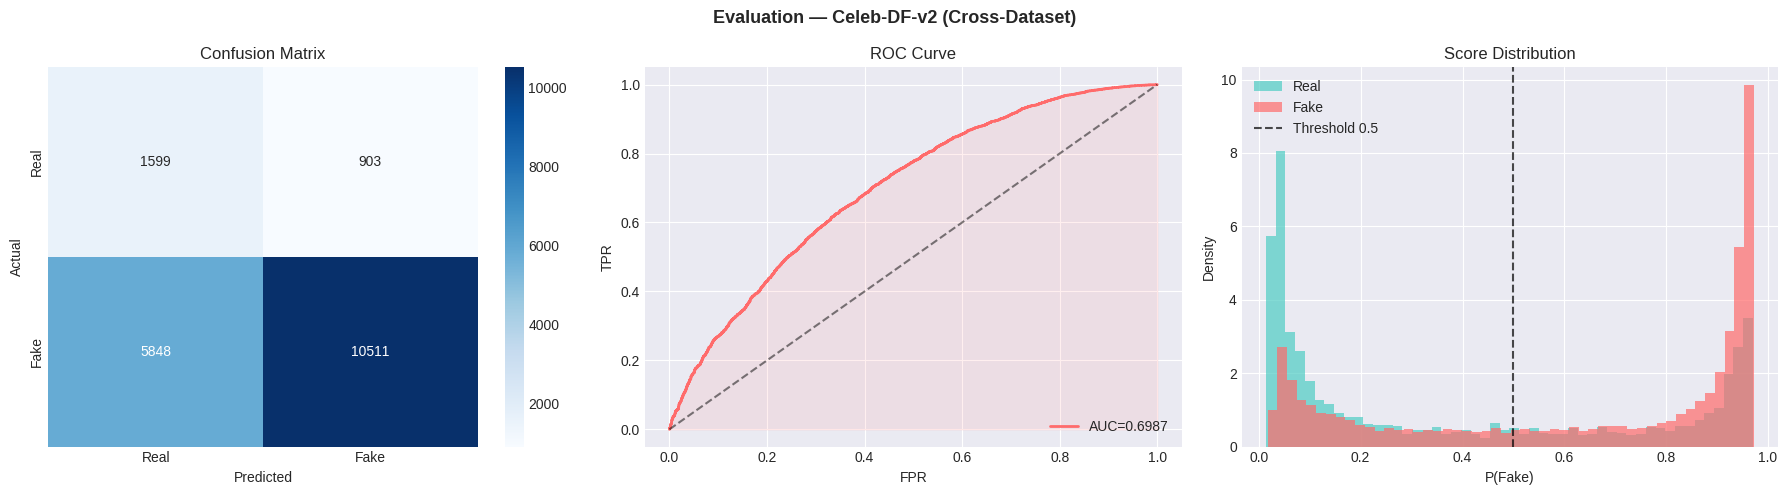


COMPARISON TABLE
Metric             FF++ Val    Celeb-DF-v2
--------------------------------------------
accuracy             84.43%          64.21%
auc                  0.9255          0.6987
eer                1510.13%        3585.13%
f1                   0.8432          0.7569
precision            0.8123          0.9209
recall               0.8766          0.6425


In [21]:
if len(test_loader) == 0:
    print('ERROR: Celeb-DF-v2 test_loader is empty (0 samples).')
    print('Please go back to run the Extract Celeb-DF-v2 clips cell (Section 1), then re-run the DataLoader cell (Section 2) to update.')
else:
    celeb_results = evaluate_model(model, test_loader, 'Celeb-DF-v2 (Cross-Dataset)')

    print('\n' + '=' * 72)
    print('COMPARISON TABLE')
    print('=' * 72)
    print(f'{"Metric":<14} {"FF++ Val":>12} {"Celeb-DF-v2":>14}')
    print('-' * 44)
    for k in ['accuracy', 'auc', 'eer', 'f1', 'precision', 'recall']:
        ff_v    = ff_results[k]
        celeb_v = celeb_results[k]
        if k in ('accuracy', 'eer'):
            print(f'{k:<14} {ff_v*100:>11.2f}%  {celeb_v*100:>13.2f}%')
        else:
            print(f'{k:<14} {ff_v:>12.4f}  {celeb_v:>14.4f}')

---
## Section 8: Ablation Study (Fair Comparison)

**Design ensures fairness:**
- All variants: `ABLATION_EPOCHS` epochs, same scheduler, same gradient clip
- Swin-based variants: differential LR (Swin=2e-5, other=1e-4) consistent
- rPPG-only variant: uniform LR=1e-4 (no Swin)
- This is a quick comparison — explicitly noted, do not use to claim absolute numbers

| Variant | Spatial | Temporal Bio | Fusion |
|---|---|---|---|
| **A** Swin Only | Swin-Tiny | ✗ | — |
| **B** rPPG Only | ✗ | rPPGNetwork3D | — |
| **C** Concat | Swin-Tiny | rPPGNetwork3D | Cat(768+64) → MLP |
| **D** Full (V7) | Swin-Tiny | rPPGNetwork3D | Multi-Head CrossAttn |


In [22]:
class SwinOnlyModel(nn.Module):
    '''Ablation A: Spatial features only (Swin-Small).'''
    def __init__(self):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224', pretrained=True, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid())

    def forward(self, spatial_input, bio_input):
        return self.classifier(self.swin(spatial_input))


class rPPGOnlyModel(nn.Module):
    '''
    Ablation B: Temporal physiological features only.
    rppg_net returns a (B, BIO_TOKENS, BIO_DIM) token sequence —
    mean-pool across tokens to get a single (B, BIO_DIM) vector for this baseline,
    since there is no cross-attention here to consume the full sequence.
    '''
    def __init__(self):
        super().__init__()
        self.rppg_net = rPPGNetwork3D(
            bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS)
        self.classifier = nn.Sequential(
            nn.Linear(Config.BIO_DIM, 128), nn.BatchNorm1d(128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, spatial_input, bio_input):
        tokens = self.rppg_net(bio_input)      # (B, BIO_TOKENS, BIO_DIM)
        pooled = tokens.mean(dim=1)             # (B, BIO_DIM) — simple temporal average
        return self.classifier(pooled)


class ConcatFusionModel(nn.Module):
    '''
    Ablation C: Concat fusion baseline (no attention at all).
    Bio tokens mean-pooled to a single vector, then concatenated with spatial.
    '''
    def __init__(self):
        super().__init__()
        self.swin     = timm.create_model(
            'swin_small_patch4_window7_224', pretrained=True, num_classes=0)
        self.rppg_net = rPPGNetwork3D(
            bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS)
        in_dim = Config.SPATIAL_DIM + Config.BIO_DIM
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, spatial_input, bio_input):
        s = self.swin(spatial_input)
        b_tokens = self.rppg_net(bio_input)     # (B, BIO_TOKENS, BIO_DIM)
        b = b_tokens.mean(dim=1)                 # (B, BIO_DIM)
        return self.classifier(torch.cat((s, b), dim=1))


print('Ablation model variants defined (Swin-Small, rPPG outputs 16 token sequences,'
      ' mean-pooled for non-attention baselines).')


Ablation model variants defined (Swin-Small, rPPG outputs 16 token sequences, mean-pooled for non-attention baselines).


In [24]:
def ablation_train_eval(model_cls, variant_name):
    '''
    Train ablation variant under consistent conditions.
    Fair comparison with V7 full model:
      - Same differential LR (Swin vs others) if Swin is used
      - Same CosineAnnealingLR schedule
      - Same gradient clipping
    Note: fewer epochs than full training — results are indicative, not absolute.
    '''
    print(f'\n{"─"*50}\n{variant_name}\n{"─"*50}')
    m = model_cls().to(device)
    crit = LabelSmoothingBCELoss()

    # Consistent Differential LR — if Swin is present, Swin LR is lower
    try:
        swin_p  = list(m.swin.parameters())
        other_p = [p for n, p in m.named_parameters() if not n.startswith('swin')]
        opt = optim.AdamW([
            {'params': swin_p,  'lr': Config.LR_SWIN},
            {'params': other_p, 'lr': Config.LR_OTHER}
        ], weight_decay=Config.WEIGHT_DECAY)
    except AttributeError:
        # rPPG-only: no Swin, use uniform LR
        opt = optim.AdamW(m.parameters(), lr=Config.LR_OTHER,
                          weight_decay=Config.WEIGHT_DECAY)

    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=Config.ABLATION_EPOCHS, eta_min=1e-7)

    for ep in range(1, Config.ABLATION_EPOCHS + 1):
        m.train()
        for imgs, bios, labels in tqdm(
                train_loader, desc=f'  Ep{ep:02d}', leave=False):
            imgs, bios, labels = imgs.to(device), bios.to(device), labels.to(device)
            opt.zero_grad()
            out  = m(imgs, bios)

            # Handle V7 tuple output (main_out, aux_out) vs single tensor
            if isinstance(out, tuple):
                main_out, aux_out = out
                main_loss = crit(main_out.squeeze(1), labels)
                aux_loss  = crit(aux_out.squeeze(1), labels)
                loss = main_loss + 0.3 * aux_loss
            else:
                loss = crit(out.squeeze(1), labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), Config.GRAD_CLIP)
            opt.step()
        sched.step()

    # Evaluate on val set
    m.eval()
    v_labels, v_probs = [], []
    with torch.no_grad():
        for imgs, bios, labels in val_loader:
            imgs, bios = imgs.to(device), bios.to(device)
            out = m(imgs, bios)
            out = out[0].squeeze(1) if isinstance(out, tuple) else out.squeeze(1)
            v_labels.extend(labels.numpy())
            v_probs.extend(out.cpu().numpy())

    y_true = np.array(v_labels)
    y_prob = np.array(v_probs)
    acc = accuracy_score(y_true, (y_prob > 0.5).astype(int))
    auc = roc_auc_score(y_true, y_prob)
    eer = compute_eer(y_true, y_prob)
    print(f'  Acc={acc*100:.2f}%  AUC={auc:.4f}  EER={eer:.2f}%')

    del m, opt, sched, crit
    torch.cuda.empty_cache(); gc.collect()
    return {'accuracy': acc, 'auc': auc, 'eer': eer}


print(f'ABLATION STUDY  |  {Config.ABLATION_EPOCHS} epochs per variant')
print(f'(Indicative comparison — full model trained for {Config.EPOCHS} epochs)')
print('=' * 60)

ablation_results = {}
for name, cls in [
    ('A: Swin Only',           SwinOnlyModel),
    ('B: rPPG 3D Only',        rPPGOnlyModel),
    ('C: Concat Fusion',       ConcatFusionModel),
    ('D: Cross-Attn V7 (Full)', DeepfakeFusionModelV7),
]:
    ablation_results[name] = ablation_train_eval(cls, name)


ABLATION STUDY  |  10 epochs per variant
(Indicative comparison — full model trained for 25 epochs)

──────────────────────────────────────────────────
A: Swin Only
──────────────────────────────────────────────────


  Ep01:   0%|          | 0/567 [00:00<?, ?it/s]

  Ep02:   0%|          | 0/567 [00:00<?, ?it/s]

  Ep03:   0%|          | 0/567 [00:00<?, ?it/s]

  Ep04:   0%|          | 0/567 [00:00<?, ?it/s]

...

  Ep07:   0%|          | 0/567 [00:00<?, ?it/s]

  Ep08:   0%|          | 0/567 [00:00<?, ?it/s]

  Ep09:   0%|          | 0/567 [00:00<?, ?it/s]

  Ep10:   0%|          | 0/567 [00:00<?, ?it/s]

  Acc=83.11%  AUC=0.9157  EER=16.57%



ABLATION RESULTS
Variant                        Accuracy      AUC      EER
----------------------------------------------------------
A: Swin Only                     85.75%   0.9147   14.55%
B: rPPG 3D Only                  59.37%   0.6286   41.92%
C: Concat Fusion                 85.31%   0.9230   14.55%
D: Cross-Attn V7 (Full)          83.11%   0.9157   16.57% ←


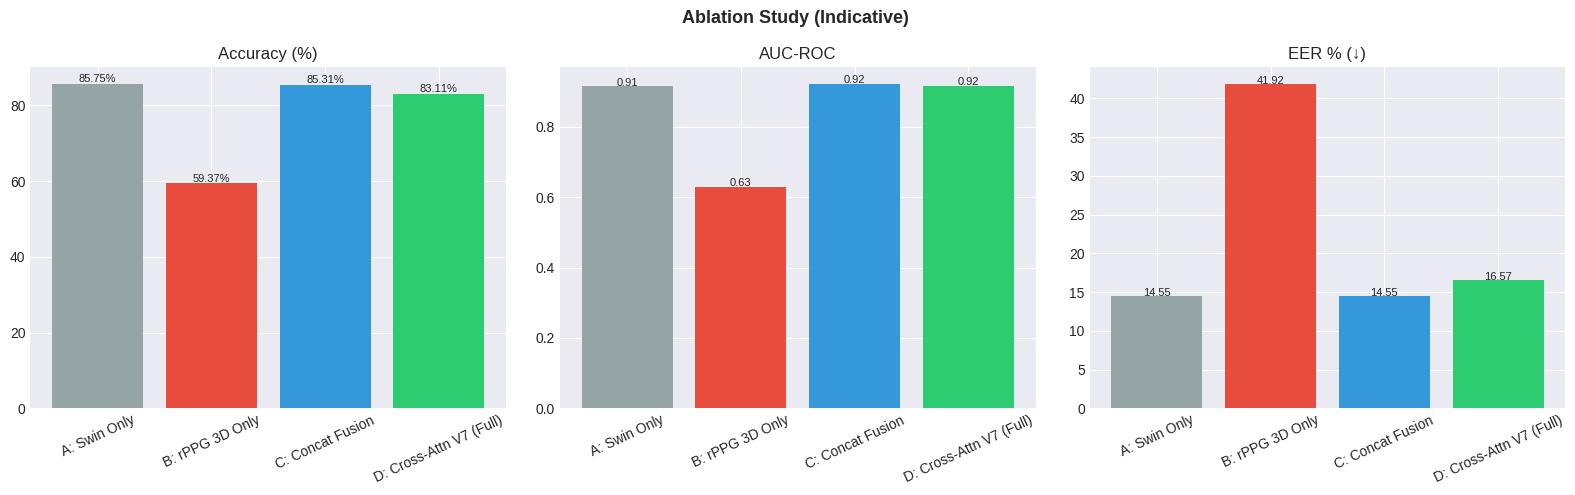

In [25]:
print('\n' + '=' * 58)
print('ABLATION RESULTS')
print('=' * 58)
print(f'{"Variant":<28} {"Accuracy":>10} {"AUC":>8} {"EER":>8}')
print('-' * 58)
for name, r in ablation_results.items():
    marker = ' ←' if 'Full' in name else ''
    print(f'{name:<28} {r["accuracy"]*100:>9.2f}%  {r["auc"]:>7.4f}  '
          f'{r["eer"]:>6.2f}%{marker}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ablation Study (Indicative)', fontsize=13, fontweight='bold')
names  = list(ablation_results.keys())
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']

for ax, metric, label, scale in [
    (axes[0], 'accuracy', 'Accuracy (%)', 100),
    (axes[1], 'auc',      'AUC-ROC',       1),
    (axes[2], 'eer',      'EER % (↓)',     1),
]:
    vals = [ablation_results[n][metric] * scale for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.5 if scale==100 else 0.002),
                f'{v:.2f}{"%" if scale==100 else ""}',
                ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'ablation_v7.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9: Export & Final Summary

In [26]:
model.load_state_dict(torch.load(best_path, map_location=device))

final_name    = f'fusion_model_v7_auc{best_val_auc:.3f}_ep{best_epoch:02d}.pth'
final_path    = os.path.join(Config.SAVE_DIR, final_name)
backend_path  = os.path.join(Config.SAVE_DIR, 'fusion_model_v7_best.pth')
torch.save(model.state_dict(), final_path)
torch.save(model.state_dict(), backend_path)

print('=' * 60)
print('TRAINING COMPLETE — FINAL SUMMARY')
print('=' * 60)
total_p = sum(p.numel() for p in model.parameters())
print(f'  Model:            DeepfakeFusionModel V7')
print(f'  Total parameters: {total_p:,}')
print(f'  Best epoch:       {best_epoch}')
print(f'  Best val AUC:     {best_val_auc:.4f}')
print(f'\n  FF++ Val results:')
for k, v in ff_results.items():
    s = f'{v*100:.2f}%' if k in ('accuracy','eer') else f'{v:.4f}'
    print(f'    {k:<12}: {s}')
print(f'\n  Celeb-DF-v2 (Cross-Dataset):')
for k, v in celeb_results.items():
    s = f'{v*100:.2f}%' if k in ('accuracy','eer') else f'{v:.4f}'
    print(f'    {k:<12}: {s}')
print(f'\n  Saved to: {Config.SAVE_DIR}/')
!ls -lh "{Config.SAVE_DIR}/"
print('\nDone!')

TRAINING COMPLETE — FINAL SUMMARY
  Model:            DeepfakeFusionModel V7
  Total parameters: 54,945,740
  Best epoch:       10
  Best val AUC:     0.9255

  FF++ Val results:
    accuracy    : 84.43%
    auc         : 0.9255
    eer         : 1510.13%
    f1          : 0.8432
    precision   : 0.8123
    recall      : 0.8766

  Celeb-DF-v2 (Cross-Dataset):
    accuracy    : 64.21%
    auc         : 0.6987
    eer         : 3585.13%
    f1          : 0.7569
    precision   : 0.9209
    recall      : 0.6425

  Saved to: /content/drive/MyDrive/DoAn_Nhom4/weights_v7/
total 1.3G
-rw------- 1 root root  78K Jun 28 05:27 ablation_v7.png
-rw------- 1 root root  82K Jun 28 03:18 attention_analysis_v7.png
-rw------- 1 root root 210M Jun 28 02:48 best_model_v7.pth
-rw------- 1 root root 104K Jun 28 03:23 eval_celeb-df-v2_cross-dataset.png
-rw------- 1 root root  98K Jun 28 03:16 eval_faceforensics++_val_c23.png
-rw------- 1 root root 210M Jun 28 05:27 fusion_model_v7_auc0.925_ep10.pth
-rw----